# 🚗 YOLOv11s — Parking Slot Detection
> Detects **Occupied** and **Empty** parking slots in video footage.
>
> **Dataset:** 913 images · mixed resolutions (640² to 3000×4000) · imbalanced classes

---
### 📋 Notebook Sections
1. Install Dependencies
2. GPU & RAM Environment Check
3. Download & Extract Dataset
4. Pre-process — Normalise Image Resolutions
5. Split Dataset (Stratified Train / Val / Test)
6. Create YAML Config
7. EDA — Class Distribution & Sample Visualisation
8. Compute Class Weights for Imbalance
9. Train YOLOv11s
10. Evaluate on Test Set
11. Visualise Training Results
12. Download Artifacts
---

## 1 · Install Dependencies

In [1]:
!pip install -q --upgrade pip
!pip install -q ultralytics gdown Pillow

import ultralytics
ultralytics.checks()

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


## 2 · GPU & RAM Environment Check

In [2]:
import torch, psutil, os

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu     = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f"GPU      : {gpu.name}")
    print(f"VRAM     : {vram_gb:.1f} GB")
    if vram_gb < 10:
        print("⚠️  Low VRAM — use BATCH_SIZE=8 in Section 9.")
    else:
        print("✅  VRAM OK for batch=16.")
else:
    raise RuntimeError("No GPU — go to Runtime → Change runtime type → T4 GPU.")

ram_gb = psutil.virtual_memory().total / 1e9
print(f"System RAM : {ram_gb:.1f} GB")

# Auto-select caching strategy.
CACHE_MODE = 'disk' if ram_gb < 14 else 'ram'
print(f"Cache mode : '{CACHE_MODE}'  (auto-selected)")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB
✅  VRAM OK for batch=16.
System RAM : 13.6 GB
Cache mode : 'disk'  (auto-selected)


## 3 · Download & Extract Dataset

In [3]:
import gdown
from pathlib import Path

FILE_ID    = '1W5iftmbBYsm4kFZvC6ueNEhpioFMOoj6'
OUTPUT_ZIP = '/content/ParkingDS.zip'
TEMP_DIR   = Path('/content/temp_data')

if not Path(OUTPUT_ZIP).exists():
    print("Downloading dataset …")
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUTPUT_ZIP, quiet=False)
else:
    print("Zip already present — skipping download.")

if not TEMP_DIR.exists():
    print("Extracting …")
    TEMP_DIR.mkdir(parents=True, exist_ok=True)
    os.system(f'unzip -q "{OUTPUT_ZIP}" -d "{TEMP_DIR}"')
    print("✅  Extraction complete.")
else:
    print("Already extracted — skipping.")

print("\nDataset structure:")
for p in sorted(TEMP_DIR.rglob('*')):
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f"  {str(p.relative_to(TEMP_DIR)):30s}  ({n} files)")

Downloading...
From (original): https://drive.google.com/uc?id=1W5iftmbBYsm4kFZvC6ueNEhpioFMOoj6
From (redirected): https://drive.google.com/uc?id=1W5iftmbBYsm4kFZvC6ueNEhpioFMOoj6&confirm=t&uuid=3ab36296-e188-4bc8-a8d1-e20fac7937d6
To: /content/ParkingDS.zip
100%|██████████| 544M/544M [00:05<00:00, 102MB/s] 


Extracting …
✅  Extraction complete.

Dataset structure:
  train                           (2 files)
  train/images                    (913 files)
  train/labels                    (913 files)


## 4 · Pre-process — Normalise Image Resolutions

The dataset contains mixed source resolutions:
- **~760 images** at 640×640 — no action needed  
- **~100 images** at 1280×1280 — downsample  
- **~20–30 images** at 3000×4000 — downsample  

YOLO letterboxes at runtime regardless, but large source images (3000×4000) cause CPU decode spikes on every epoch. Pre-resizing to 640 eliminates this overhead. YOLO labels are normalised to 0–1 so they remain valid after resize

In [4]:
from PIL import Image as PILImage
import concurrent.futures
from collections import Counter

TARGET_SIZE  = 640
RESIZE_ABOVE = 640    # Resize anything with longest edge > 640
IMG_DIR      = TEMP_DIR / 'train' / 'images'

valid_ext  = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
all_images = [p for p in IMG_DIR.iterdir() if p.suffix.lower() in valid_ext]

# ── Audit resolution distribution ────────────────────────────────────────────
size_buckets = Counter()
for p in all_images:
    try:
        w, h = PILImage.open(p).size
        side = max(w, h)
        if side <= 640:
            size_buckets['≤640'] += 1
        elif side <= 1280:
            size_buckets['641-1280'] += 1
        elif side <= 2000:
            size_buckets['1281-2000'] += 1
        else:
            size_buckets['>2000'] += 1
    except Exception:
        size_buckets['unreadable'] += 1

print("Resolution distribution BEFORE resize:")
for bucket, count in sorted(size_buckets.items()):
    print(f"  {bucket:>12} px  →  {count} images")

# ── Parallel in-place resize ──────────────────────────────────────────────────
def resize_image(p):
    try:
        img  = PILImage.open(p)
        w, h = img.size
        if max(w, h) <= RESIZE_ABOVE:
            return None
        scale        = TARGET_SIZE / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        resized      = img.convert('RGB').resize((new_w, new_h), PILImage.LANCZOS)
        out_path     = p.with_suffix('.jpg')
        resized.save(out_path, 'JPEG', quality=95)
        if out_path != p:
            p.unlink()
        return p.name
    except Exception as e:
        return f'ERROR:{p.name}:{e}'

print("\nResizing images > 640px …")
resized, errors = [], []
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as ex:
    for result in ex.map(resize_image, all_images):
        if result is None:
            pass
        elif result.startswith('ERROR'):
            errors.append(result)
        else:
            resized.append(result)

print(f"  Resized  : {len(resized)} images")
print(f"  Unchanged: {len(all_images) - len(resized) - len(errors)} images")
if errors:
    print(f"  Errors   : {len(errors)}")
    for e in errors[:5]: print(f"    {e}")
print("✅  Resolution normalisation complete.")

Resolution distribution BEFORE resize:
     1281-2000 px  →  203 images
      641-1280 px  →  205 images
         >2000 px  →  118 images
          ≤640 px  →  387 images

Resizing images > 640px …
  Resized  : 526 images
  Unchanged: 387 images
✅  Resolution normalisation complete.


## 5 · Split Dataset — Stratified Train / Val / Test

Standard random splitting with 913 imbalanced images risks putting almost all minority-class examples in train. **Stratified splitting** groups images by their dominant class label and interleaves them before splitting, so each fold gets a representative mix.

In [5]:
import random, shutil
from collections import Counter, defaultdict

SEED        = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20

source_images = TEMP_DIR / 'train' / 'images'
source_labels = TEMP_DIR / 'train' / 'labels'
already_split = (TEMP_DIR / 'valid').exists()

def dominant_class(lbl_path):
    """Most frequent class id in a label file; -1 if missing or empty."""
    if not Path(lbl_path).exists():
        return -1
    classes = []
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                classes.append(int(parts[0]))
    return Counter(classes).most_common(1)[0][0] if classes else -1

if not already_split and source_images.exists():
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
    images    = sorted([f for f in os.listdir(source_images)
                        if f.lower().endswith(valid_ext)])

    # Group by dominant class
    groups = defaultdict(list)
    for img in images:
        cls = dominant_class(source_labels / (Path(img).stem + '.txt'))
        groups[cls].append(img)

    # Shuffle within each group, then interleave
    random.seed(SEED)
    for g in groups.values():
        random.shuffle(g)

    stratified, iters = [], [iter(g) for g in groups.values()]
    while iters:
        next_iters = []
        for it in iters:
            try:
                stratified.append(next(it))
                next_iters.append(it)
            except StopIteration:
                pass
        iters = next_iters

    total     = len(stratified)
    train_end = int(total * TRAIN_RATIO)
    val_end   = train_end + int(total * VAL_RATIO)
    splits    = {'valid': stratified[train_end:val_end],
                 'test' : stratified[val_end:]}

    def move_split(file_list, split_name):
        img_dst = TEMP_DIR / split_name / 'images'
        lbl_dst = TEMP_DIR / split_name / 'labels'
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_dst.mkdir(parents=True, exist_ok=True)
        moved = 0
        for img in file_list:
            src_img = source_images / img
            src_lbl = source_labels / (Path(img).stem + '.txt')
            if src_img.exists():
                shutil.move(str(src_img), str(img_dst / img)); moved += 1
            if src_lbl.exists():
                shutil.move(str(src_lbl), str(lbl_dst / src_lbl.name))
        return moved

    for split, flist in splits.items():
        n = move_split(flist, split)
        print(f"  {split:>5}: {n} images")

    train_count = len(list((TEMP_DIR / 'train' / 'images').glob('*')))
    print(f"\n✅  Stratified split → "
          f"train: {train_count} | valid: {len(splits['valid'])} | "
          f"test: {len(splits['test'])}  (total: {total})")
else:
    for split in ['train', 'valid', 'test']:
        p = TEMP_DIR / split / 'images'
        n = len(list(p.glob('*'))) if p.exists() else 0
        print(f"  {split:>5}: {n} images")
    print("ℹ️  Dataset already split.")

  valid: 182 images
   test: 92 images

✅  Stratified split → train: 639 | valid: 182 | test: 92  (total: 913)


## 6 · Create YAML Config

In [6]:
YAML_PATH    = '/content/data.yaml'
DATASET_ROOT = '/content/temp_data'

yaml_content = f"""# Parking Slot Detection — YOLOv11s
path: {DATASET_ROOT}
train: train/images
val:   valid/images
test:  test/images

nc: 2
names: ['Occupied', 'Empty']
"""

with open(YAML_PATH, 'w') as f:
    f.write(yaml_content)

print("✅  data.yaml written:")
print(yaml_content)

✅  data.yaml written:
# Parking Slot Detection — YOLOv11s
path: /content/temp_data
train: train/images
val:   valid/images
test:  test/images

nc: 2
names: ['Occupied', 'Empty']



## 7 · EDA — Class Distribution & Sample Visualisation

Split  Images  Occupied  Empty  Total BBoxes     Occ/Emp %
train     639     11434   7543         18977 60.3% / 39.7%
valid     182      3458   2346          5804 59.6% / 40.4%
 test      92      2608   1024          3632 71.8% / 28.2%

✅  Class balance acceptable (< 65/35).


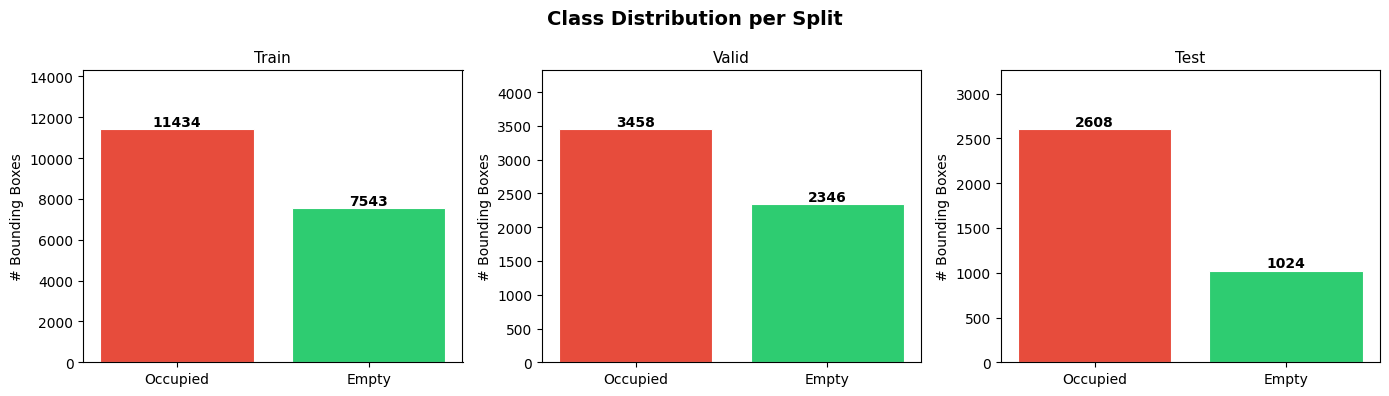

✅  Saved class_distribution.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

CLASS_NAMES  = {0: 'Occupied', 1: 'Empty'}
CLASS_COLORS = {0: '#E74C3C', 1: '#2ECC71'}

def count_classes(split):
    lbl_dir = TEMP_DIR / split / 'labels'
    counter = Counter()
    if not lbl_dir.exists():
        return counter
    for lbl in lbl_dir.glob('*.txt'):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter

splits_data = {s: count_classes(s) for s in ['train', 'valid', 'test']}

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for split, counts in splits_data.items():
    total_imgs = len(list((TEMP_DIR / split / 'images').glob('*')))
    total_bb   = sum(counts.values())
    occ        = counts.get(0, 0)
    emp        = counts.get(1, 0)
    ratio_str  = f"{occ/total_bb*100:.1f}% / {emp/total_bb*100:.1f}%" if total_bb else 'N/A'
    rows.append({'Split': split, 'Images': total_imgs,
                 'Occupied': occ, 'Empty': emp,
                 'Total BBoxes': total_bb, 'Occ/Emp %': ratio_str})

df_eda = pd.DataFrame(rows)
print(df_eda.to_string(index=False))

train_counts = splits_data['train']
total_train  = sum(train_counts.values())
if total_train > 0:
    majority_pct = max(train_counts.values()) / total_train
    if majority_pct > 0.65:
        minority_cls = min(train_counts, key=train_counts.get)
        print(f"\n⚠️  Imbalance: majority = {majority_pct*100:.1f}%  "
              f"(minority = {CLASS_NAMES[minority_cls]})")
        print("   cls_loss weight will be boosted in Section 8.")
    else:
        print("\n✅  Class balance acceptable (< 65/35).")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')
for ax, (split, counts) in zip(axes, splits_data.items()):
    labels = [CLASS_NAMES.get(k) for k in sorted(counts)]
    values = [counts[k] for k in sorted(counts)]
    colors = [CLASS_COLORS.get(k, '#888') for k in sorted(counts)]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(split.capitalize(), fontsize=11)
    ax.set_ylabel('# Bounding Boxes')
    ax.set_ylim(0, max(values) * 1.25 if values else 1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 2, str(val),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved class_distribution.png")

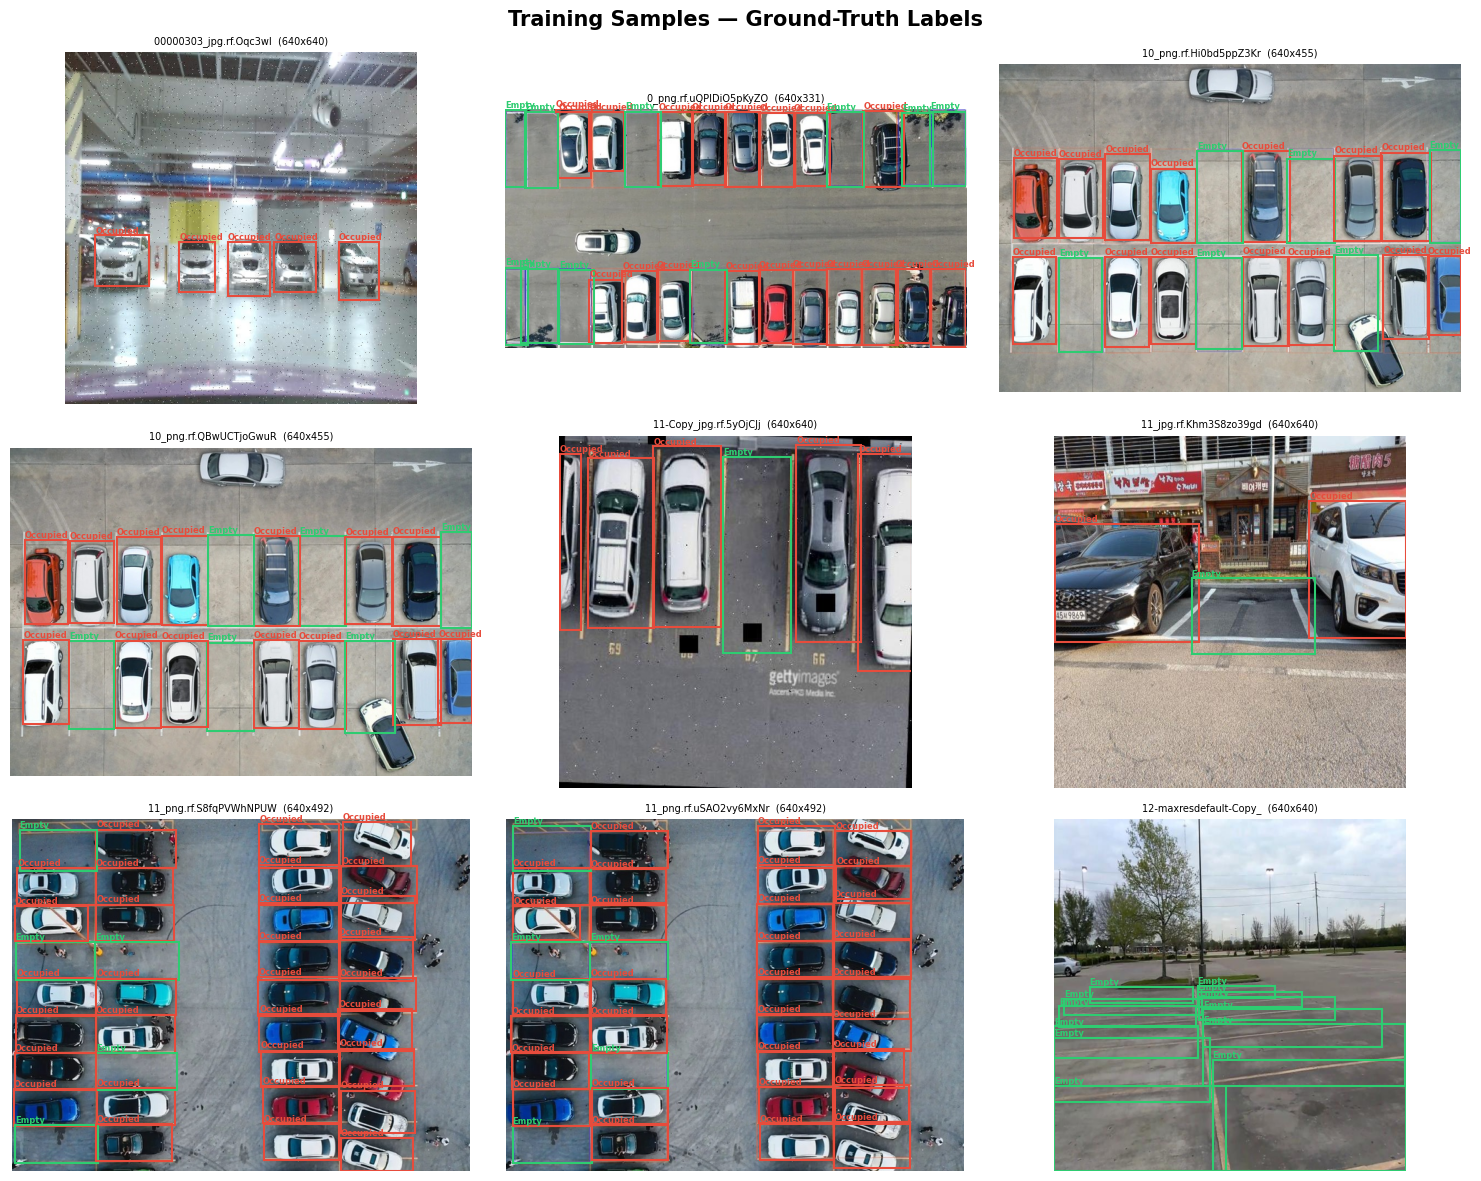

✅  Saved eda_samples.png


In [8]:
# ── 9 sample images with ground-truth boxes ───────────────────────────────────
def parse_yolo_label(lbl_path, img_w, img_h):
    boxes = []
    if not Path(lbl_path).exists():
        return boxes
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = (cx - bw / 2) * img_w
            y1 = (cy - bh / 2) * img_h
            boxes.append((cls, x1, y1, bw * img_w, bh * img_h))
    return boxes

train_imgs = sorted((TEMP_DIR / 'train' / 'images').glob('*'))[:9]
fig, axes  = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Training Samples — Ground-Truth Labels', fontsize=15, fontweight='bold')

for ax, img_path in zip(axes.flat, train_imgs):
    img    = PILImage.open(img_path).convert('RGB')
    iw, ih = img.size
    lbl    = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
    boxes  = parse_yolo_label(lbl, iw, ih)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img_path.name[:22]}  ({iw}x{ih})", fontsize=7)
    for cls, x, y, w, h in boxes:
        color = CLASS_COLORS.get(cls, 'white')
        ax.add_patch(mpatches.Rectangle((x, y), w, h,
                     linewidth=1.5, edgecolor=color, facecolor='none'))
        ax.text(x, y - 3, CLASS_NAMES.get(cls, str(cls)),
                color=color, fontsize=6, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved eda_samples.png")

## 8 · Compute Class Weights for Imbalance

YOLO's `cls` hyper-parameter scales the classification loss globally. We compute it from the actual class counts using an inverse-frequency formula, then cap it to prevent training instability.

In [9]:
occ_count = train_counts.get(0, 1)
emp_count = train_counts.get(1, 1)

majority        = max(occ_count, emp_count)
minority        = min(occ_count, emp_count)
imbalance_ratio = majority / minority

# Scale from YOLO default (0.5) — 40% of the imbalance gap, capped at 2.0
CLS_WEIGHT = round(0.5 * (1.0 + (imbalance_ratio - 1) * 0.4), 3)
CLS_WEIGHT = min(CLS_WEIGHT, 2.0)

# Revert to default if roughly balanced
if imbalance_ratio < 1.5:
    CLS_WEIGHT = 0.5

print(f"Occupied (train) : {occ_count} bboxes")
print(f"Empty    (train) : {emp_count} bboxes")
print(f"Imbalance ratio  : {imbalance_ratio:.2f}x")
print(f"cls weight       : {CLS_WEIGHT}  (default = 0.5)")

Occupied (train) : 11434 bboxes
Empty    (train) : 7543 bboxes
Imbalance ratio  : 1.52x
cls weight       : 0.603  (default = 0.5)


## 9 · Train YOLOv11s


In [10]:
from ultralytics import YOLO

EPOCHS      = 100
IMAGE_SIZE  = 640
BATCH_SIZE  = 16
PATIENCE    = 20
PROJECT_DIR = '/content/runs/parking'
RUN_NAME    = 'yolo11s_v1'

model = YOLO('yolo11s.pt')

results = model.train(
    data    = YAML_PATH,
    epochs  = EPOCHS,
    imgsz   = IMAGE_SIZE,
    batch   = BATCH_SIZE,
    patience = PATIENCE,
    rect    = False,

    # Optimiser
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    cos_lr       = True,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 5,

    # Loss weights
    cls = CLS_WEIGHT,
    box = 7.5,
    dfl = 1.5,

    # Augmentation
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 10.0,
    translate   = 0.1,
    scale       = 0.5,
    shear       = 3.0,
    perspective = 0.0005,
    flipud      = 0.2,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.15,
    copy_paste  = 0.5,

    # Performance
    cache   = CACHE_MODE,
    workers = 4,
    device  = 0,
    amp     = True,

    # Logging
    project  = PROJECT_DIR,
    name     = RUN_NAME,
    exist_ok = True,
    verbose  = True,
    plots    = True,
)

print("\n✅  Training complete!")
BEST_WEIGHTS = Path(PROJECT_DIR) / RUN_NAME / 'weights' / 'best.pt'
RUN_DIR      = Path(PROJECT_DIR) / RUN_NAME
print(f"Best weights: {BEST_WEIGHTS}")

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.603, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.000

## 10 · Evaluate on Test Set

In [11]:
best_model = YOLO(str(BEST_WEIGHTS))

metrics = best_model.val(
    data    = YAML_PATH,
    split   = 'test',
    imgsz   = IMAGE_SIZE,
    batch   = 16,
    device  = 0,
    verbose = True,
)

print("\n" + "="*55)
print("  TEST-SET METRICS")
print("="*55)
for cls_idx, cls_name in CLASS_NAMES.items():
    print(f"\n  {cls_name}")
    try:
        print(f"    Precision : {metrics.box.p[cls_idx]:.4f}")
        print(f"    Recall    : {metrics.box.r[cls_idx]:.4f}")
        print(f"    AP@0.50   : {metrics.box.ap[cls_idx]:.4f}")
    except (IndexError, AttributeError):
        print("    (per-class data unavailable)")
print(f"\n  mAP@0.50      : {metrics.box.map50:.4f}")
print(f"  mAP@0.50:0.95 : {metrics.box.map:.4f}")
print("="*55)


Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 23.5±19.7 MB/s, size: 133.9 KB)
val: Scanning /content/temp_data/test/labels... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 337.7it/s 0.3s
val: New cache created: /content/temp_data/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1139, len(boxes) = 3632. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3s/it 8.0s
                   all         92       3632       0.98      0.875      0.916      0.769
              Occupied         92       2608      0.983      0.907      0.942 

## 11 · Visualise Training Results

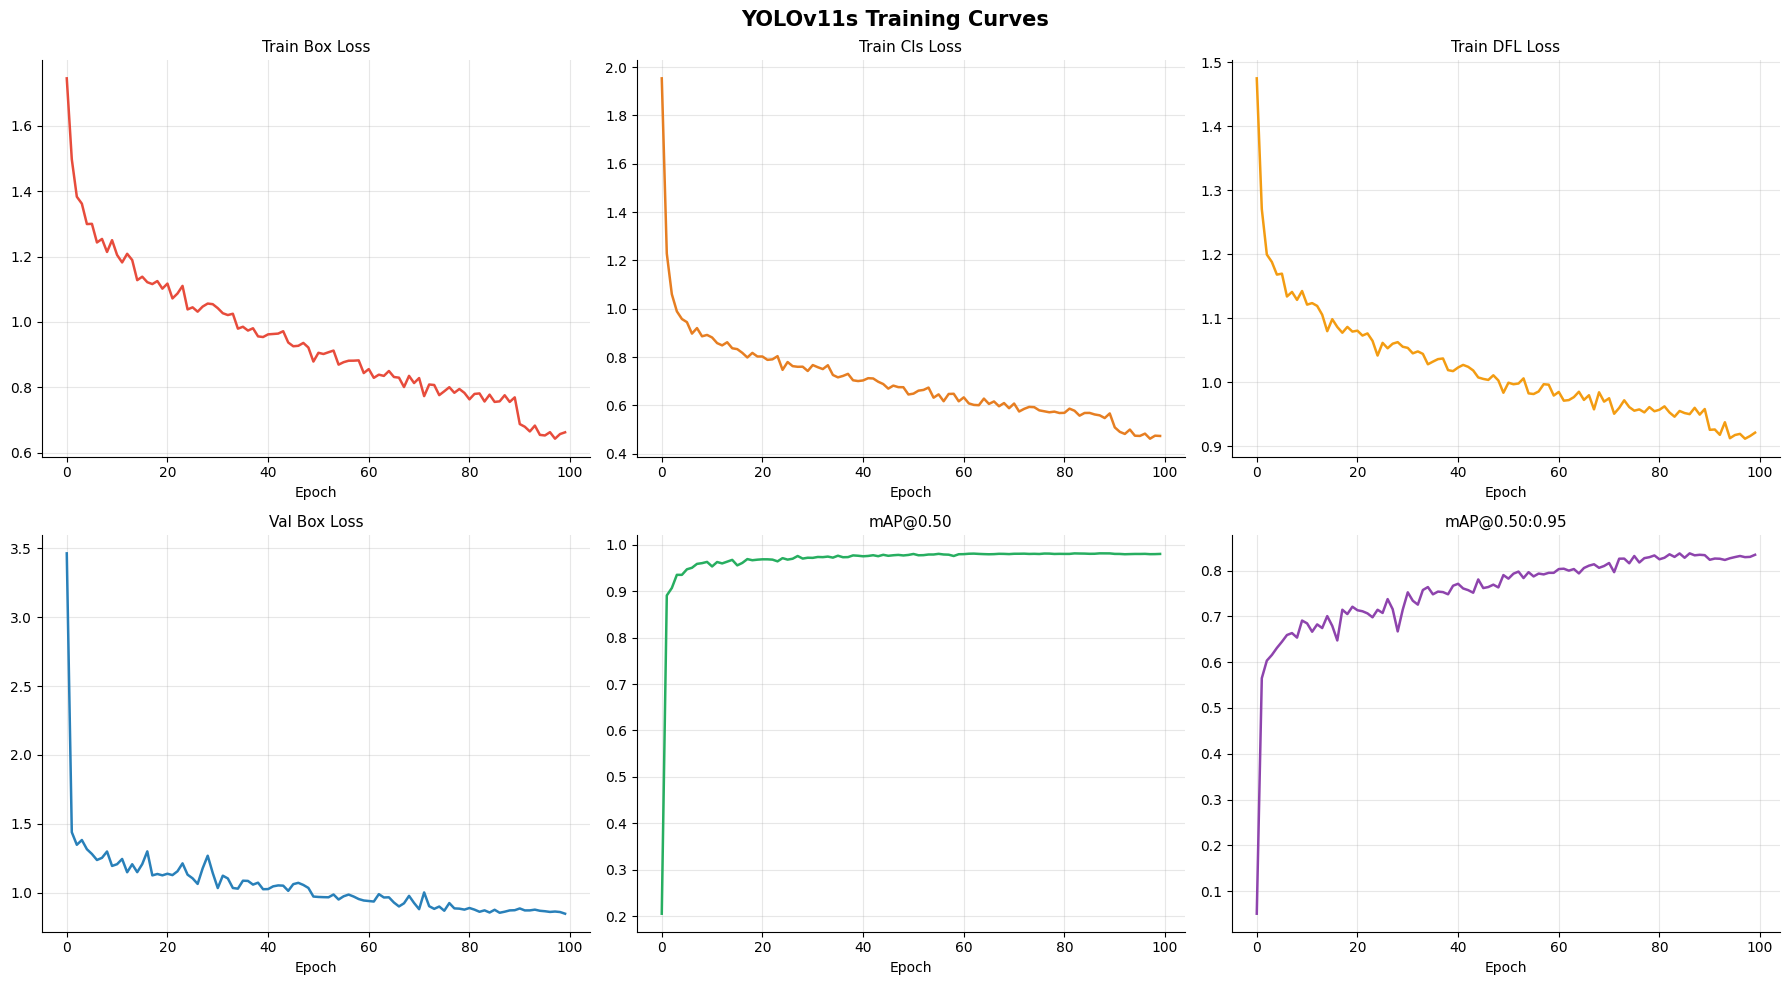

✅  Saved training_curves.png

📊  confusion_matrix_normalized.png


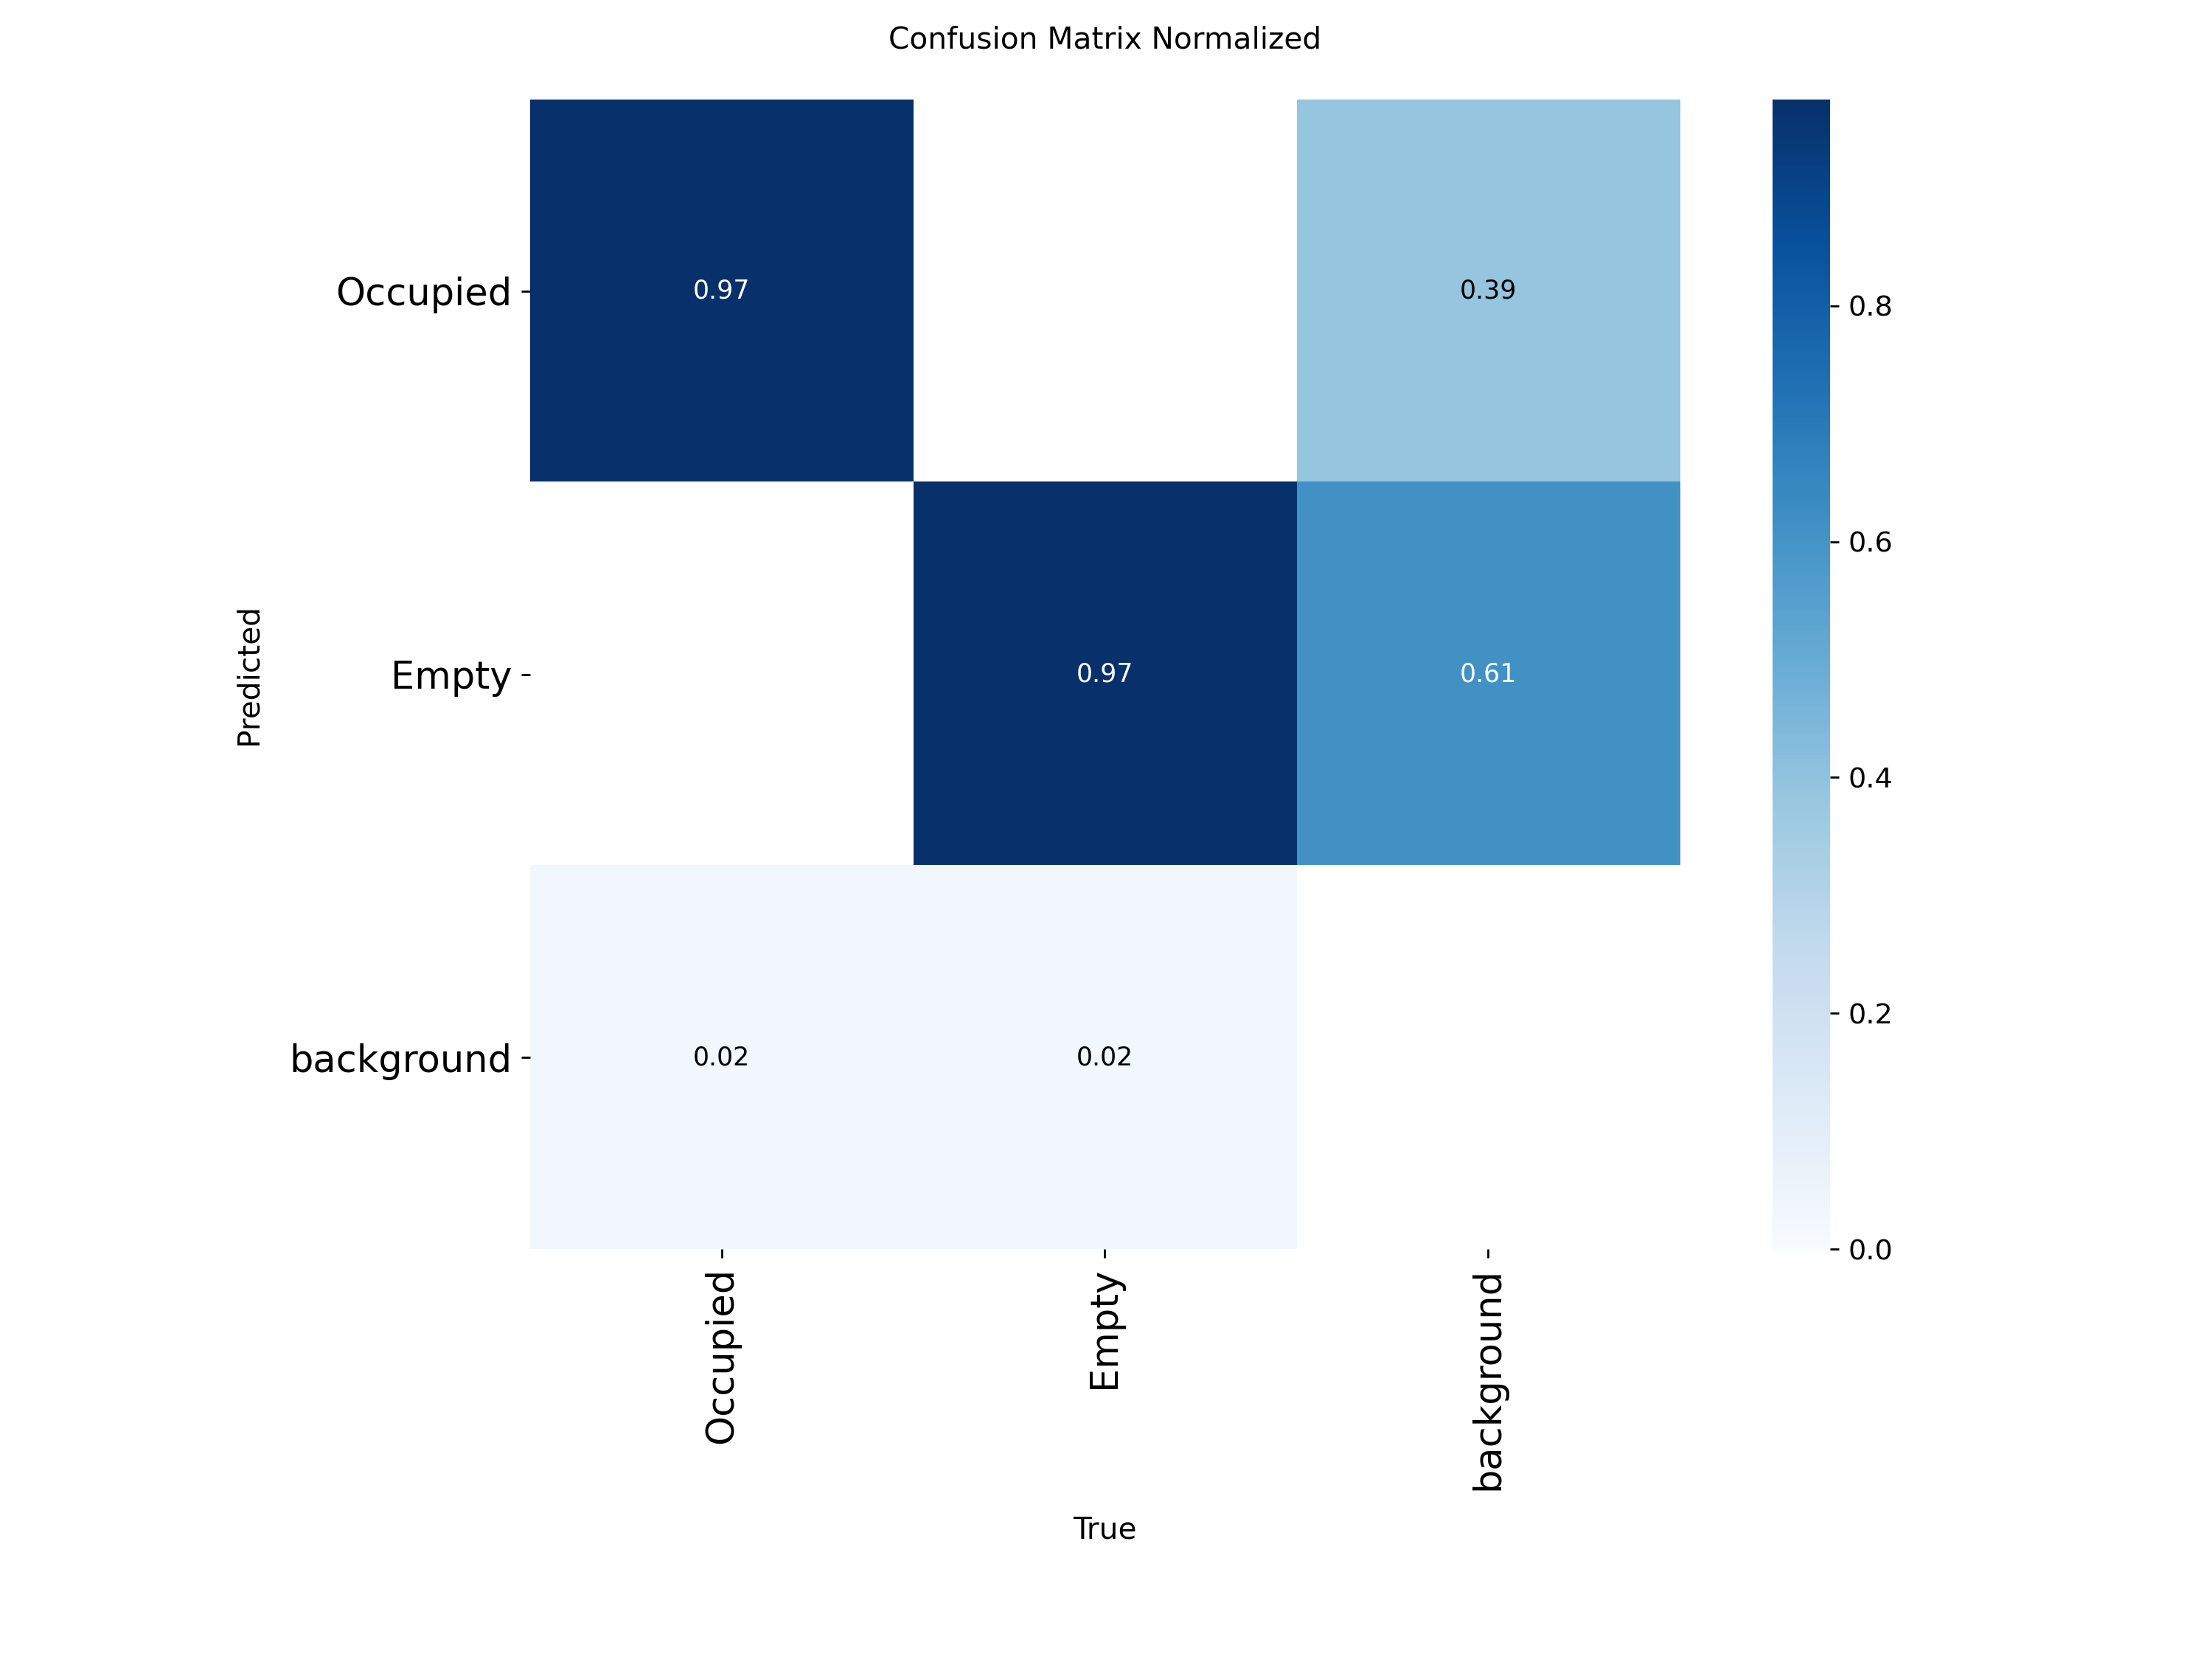


📊  val_batch0_pred.jpg


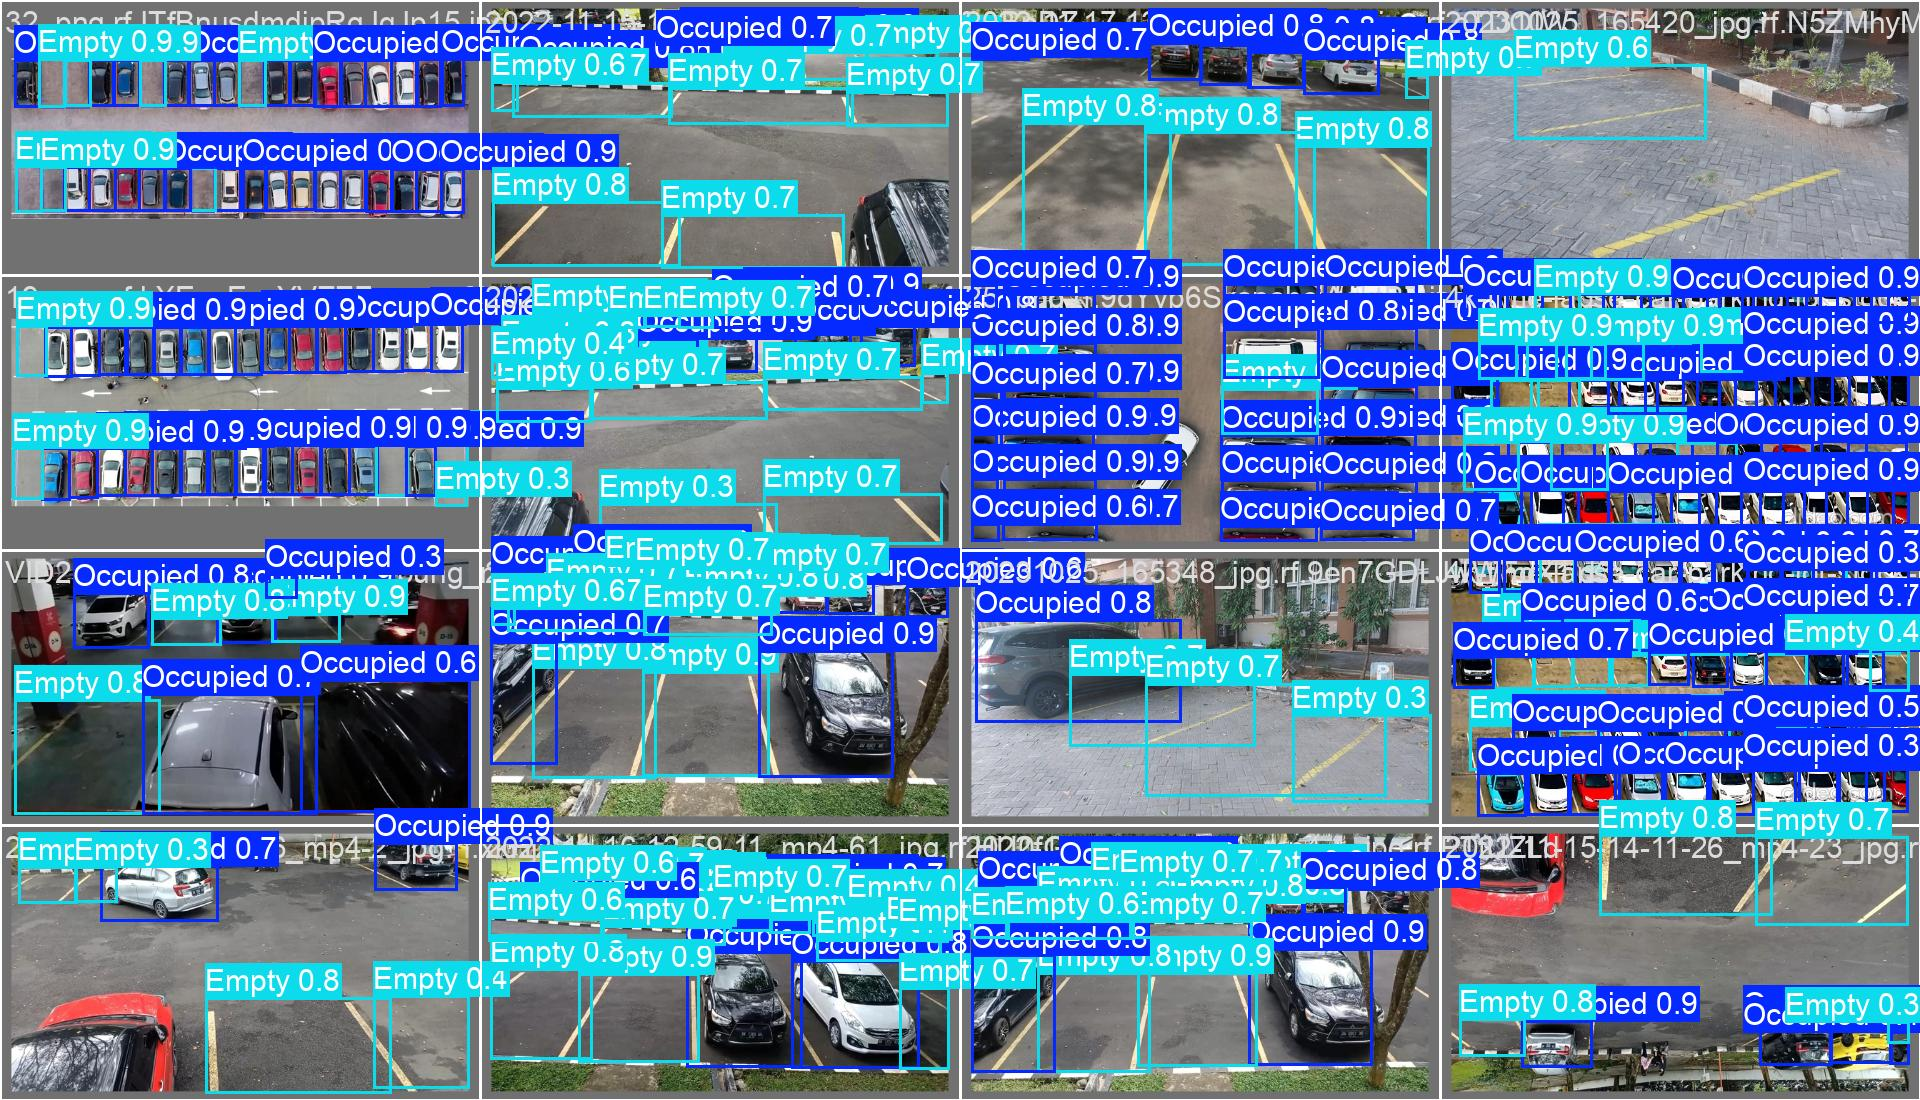

In [12]:
from IPython.display import Image as IPyImage, display

results_csv = RUN_DIR / 'results.csv'
if results_csv.exists():
    df_r = pd.read_csv(results_csv)
    df_r.columns = df_r.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('YOLOv11s Training Curves', fontsize=15, fontweight='bold')

    def safe_plot(ax, col, title, color='steelblue'):
        if col in df_r.columns:
            ax.plot(df_r[col], color=color, linewidth=1.8)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        else:
            ax.text(0.5, 0.5, f'Column not found:\n{col}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(title, fontsize=11)

    safe_plot(axes[0,0], 'train/box_loss',       'Train Box Loss',     '#E74C3C')
    safe_plot(axes[0,1], 'train/cls_loss',       'Train Cls Loss',     '#E67E22')
    safe_plot(axes[0,2], 'train/dfl_loss',       'Train DFL Loss',     '#F39C12')
    safe_plot(axes[1,0], 'val/box_loss',         'Val Box Loss',       '#2980B9')
    safe_plot(axes[1,1], 'metrics/mAP50(B)',     'mAP@0.50',           '#27AE60')
    safe_plot(axes[1,2], 'metrics/mAP50-95(B)', 'mAP@0.50:0.95',      '#8E44AD')

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅  Saved training_curves.png")
else:
    print("⚠️  results.csv not found.")

for fname in ['confusion_matrix_normalized.png', 'PR_curve.png',
              'F1_curve.png', 'val_batch0_pred.jpg']:
    fpath = RUN_DIR / fname
    if fpath.exists():
        print(f"\n📊  {fname}")
        display(IPyImage(str(fpath)))

## 12 · Download Artifacts

In [15]:
import zipfile
from google.colab import files as colab_files

ARCHIVE = '/content/parking_yolo11s_results.zip'

files_to_pack = [
    (BEST_WEIGHTS,                                 'weights/best.pt'),
    (RUN_DIR / 'weights' / 'last.pt',              'weights/last.pt'),
    ('/content/data.yaml',                         'data.yaml'),
    ('/content/training_curves.png',               'plots/training_curves.png'),
    ('/content/eda_samples.png',                   'plots/eda_samples.png'),
    ('/content/class_distribution.png',            'plots/class_distribution.png'),
    (RUN_DIR / 'confusion_matrix_normalized.png',  'plots/confusion_matrix.png'),
    (RUN_DIR / 'PR_curve.png',                     'plots/PR_curve.png'),
    (RUN_DIR / 'F1_curve.png',                     'plots/F1_curve.png'),
    (RUN_DIR / 'results.csv',                      'results.csv'),
]
onnx_candidate = BEST_WEIGHTS.parent / 'best.onnx'
if onnx_candidate.exists():
    files_to_pack.append((onnx_candidate, 'weights/best.onnx'))

with zipfile.ZipFile(ARCHIVE, 'w', zipfile.ZIP_DEFLATED) as zf:
    for src, arc_name in files_to_pack:
        src = Path(src)
        if src.exists():
            zf.write(src, arc_name)
            print(f"  ✅  {arc_name}")
        else:
            print(f"  ⚠️  Not found: {src.name}")

print(f"\n📦  {ARCHIVE}")
colab_files.download(ARCHIVE)

  ✅  weights/best.pt
  ✅  weights/last.pt
  ✅  data.yaml
  ✅  plots/training_curves.png
  ✅  plots/eda_samples.png
  ✅  plots/class_distribution.png
  ✅  plots/confusion_matrix.png
  ⚠️  Not found: PR_curve.png
  ⚠️  Not found: F1_curve.png
  ✅  results.csv

📦  /content/parking_yolo11s_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>